# 09 - Google Groundsource Flood Verification

Analyses Google Groundsource flood extent data and compares it against Floodscan SFED for selected LGAs in the Niger-Benue floodplain.

Google Groundsource polygons are derived from news reports and other non-satellite sources. Many polygons correspond to administrative unit boundaries rather than explicit flood extents, so small polygons (< 1 km²) are filtered out.

**Inputs (local / Azure):**
- `groundsource_2026.parquet` — Google Groundsource flood extents (local)
- `ds-aa-nga-flooding/processed/selected_lgas.parquet` — Selected LGAs of interest

**Outputs saved to Azure:**
- `ds-aa-nga-flooding/processed/groundsource_flood_sel.parquet` — Groundsource flood polygons intersecting selected LGAs (simplified, for interactive map)

In [1]:
import sys
import os
import calendar
import tempfile

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import seaborn as sns
from dotenv import load_dotenv
from datetime import datetime
from matplotlib.colors import LogNorm, ListedColormap
from rasterio.features import rasterize
from shapely.ops import unary_union
from tqdm.notebook import tqdm
import ocha_stratus as stratus

sys.path.append("quarto")
from ocha_style import setup_ocha_style, OCHA_COLORS

setup_ocha_style()
load_dotenv()

✓ OCHA visual style applied
✓ OCHA visual style applied


True

In [2]:
gdf_lga_sel = stratus.load_geoparquet_from_blob("ds-aa-nga-flooding/processed/selected_lgas.parquet")

If running for the first time...

In [3]:
# # Loading this locally will take a while...
# gdf = stratus.load_geoparquet_from_blob("vector/raw/groundsource_2026.parquet", container_name="global")

# # Only keep those that intersect with the selected LGAs
# gdf_flood_sel = gdf.sjoin(gdf_lga_sel, predicate="intersects")

# # Filter to only floods with area >= 1 km2, and convert date columns to datetime
# gdf_flood_sel = gdf_flood_sel[gdf_flood_sel["area_km2"] >= 1]
# gdf_flood_sel['start_date'] = pd.to_datetime(gdf_flood_sel['start_date'])
# gdf_flood_sel['end_date'] = pd.to_datetime(gdf_flood_sel['end_date'])
# gdf_flood_sel['start_year'] = gdf_flood_sel['start_date'].dt.year
# gdf_flood_sel['end_year'] = gdf_flood_sel['end_date'].dt.year
# gdf_flood_sel['start_month'] = gdf_flood_sel['start_date'].dt.month
# gdf_flood_sel['end_month'] = gdf_flood_sel['end_date'].dt.month

# # Drop duplicates from the spatial join and only keep relevant columns
# gdf_flood_sel = gdf_flood_sel.drop_duplicates(subset='uuid')

# stratus.upload_parquet_to_blob(
#     gdf_flood_sel[['uuid', 'area_km2', 'geometry', 'start_date', 'end_date', 'start_month', 'start_year', 'end_month', 'end_year']], 
#     "ds-aa-nga-flooding/processed/groundsource_flood_sel.parquet")
# print(f"Saved {len(gdf_flood_sel)} flood polygons to blob")

Once the above has been run...

In [4]:
gdf_flood_sel = stratus.load_geoparquet_from_blob("ds-aa-nga-flooding/processed/groundsource_flood_sel.parquet")
print(f"Loaded {len(gdf_flood_sel)} flood polygons from blob")

Loaded 3174 flood polygons from blob


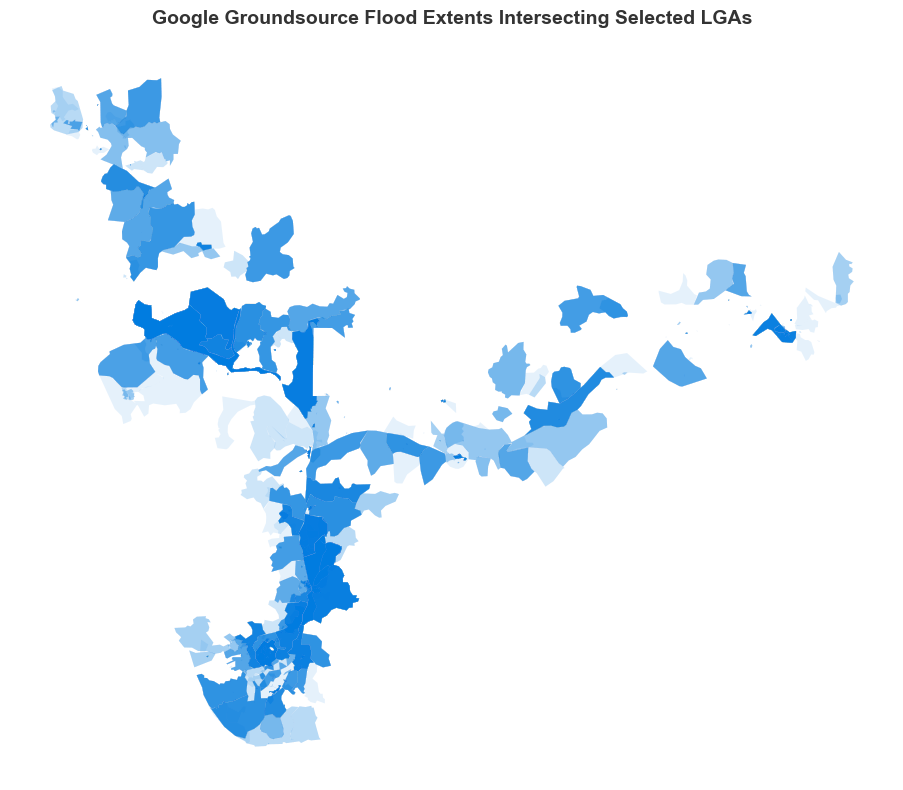

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
gdf_flood_sel.plot(
    ax=ax,
    color=OCHA_COLORS["ocha_blue"],
    alpha=0.1,
    edgecolor="white",
    linewidth=0.1,
)
ax.set_title("Google Groundsource Flood Extents Intersecting Selected LGAs")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Now some further basic cleaning

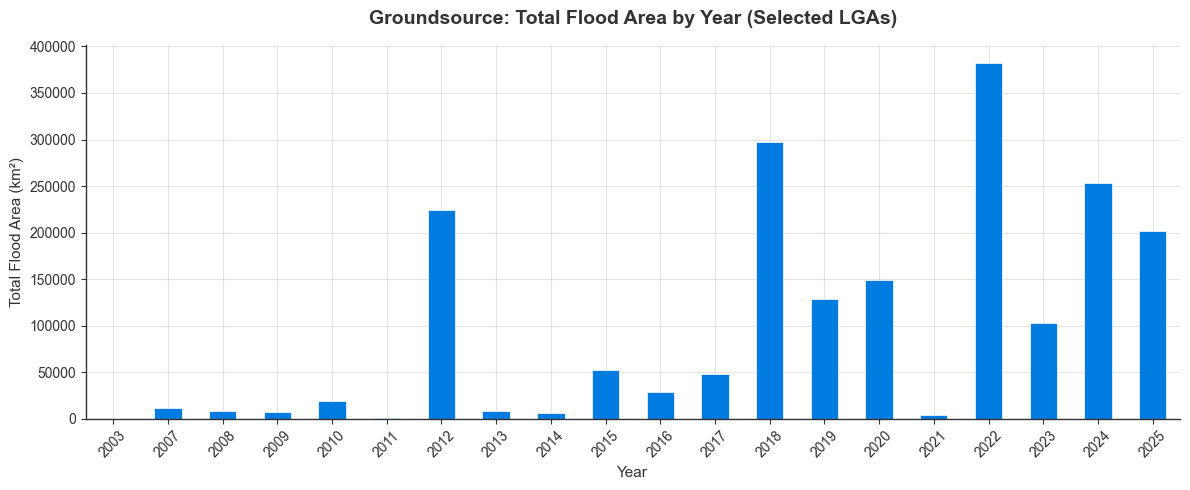

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
gdf_flood_sel.groupby("start_year")["area_km2"].sum().plot(
    kind="bar", ax=ax, color=OCHA_COLORS["ocha_blue"], edgecolor="white", linewidth=0.5
)
ax.set_title("Groundsource: Total Flood Area by Year (Selected LGAs)")
ax.set_xlabel("Year")
ax.set_ylabel("Total Flood Area (km²)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figures/groundsource_flood_area_by_year.png", dpi=300)

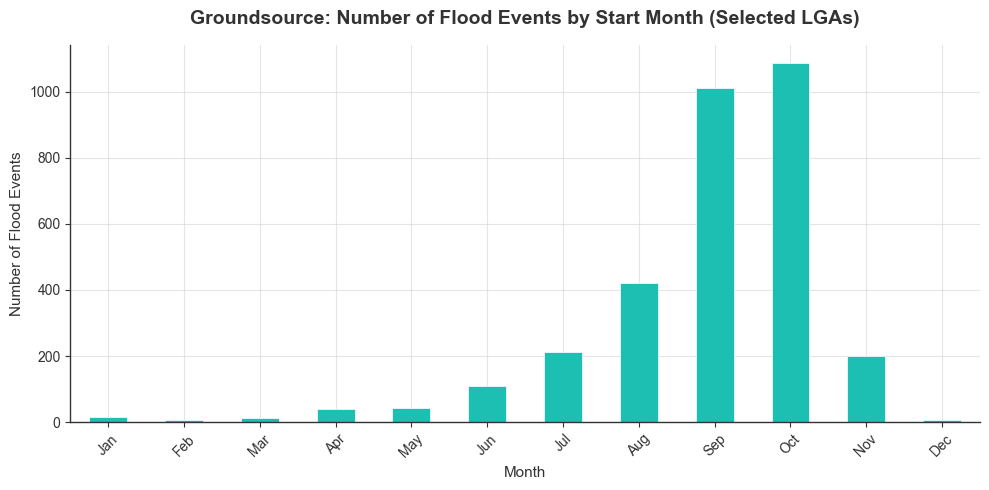

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
monthly_counts = gdf_flood_sel.groupby("start_month").size()
monthly_counts.index = [calendar.month_abbr[m] for m in monthly_counts.index]
monthly_counts.plot(
    kind="bar", ax=ax, color=OCHA_COLORS["teal"], edgecolor="white", linewidth=0.5
)
ax.set_title("Groundsource: Number of Flood Events by Start Month (Selected LGAs)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Flood Events")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figures/groundsource_flood_events_by_month.png", dpi=300)

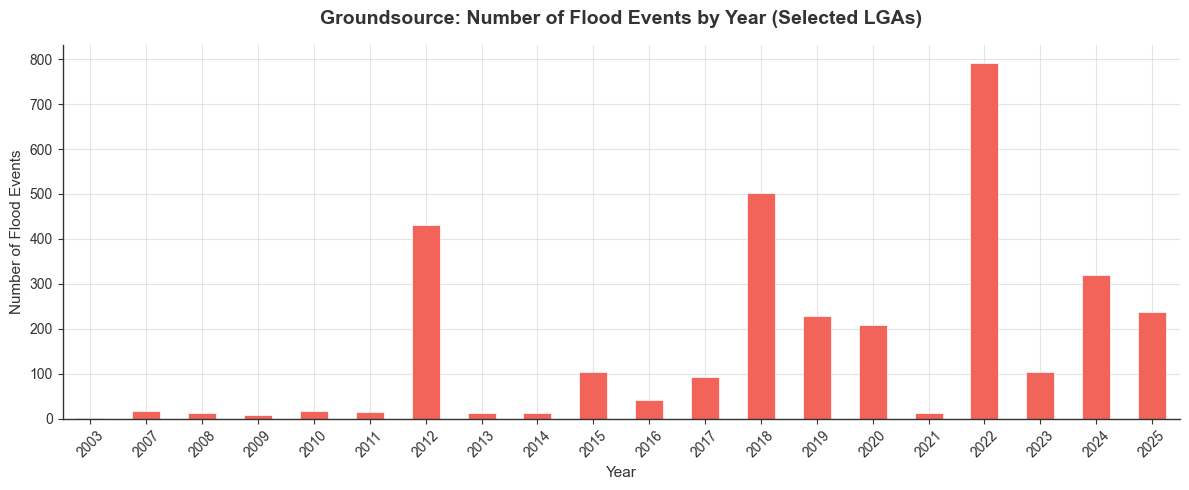

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
gdf_flood_sel.groupby("start_year").size().plot(
    kind="bar", ax=ax, color=OCHA_COLORS["coral"], edgecolor="white", linewidth=0.5
)
ax.set_title("Groundsource: Number of Flood Events by Year (Selected LGAs)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Flood Events")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("figures/groundsource_flood_events_by_year.png", dpi=300)

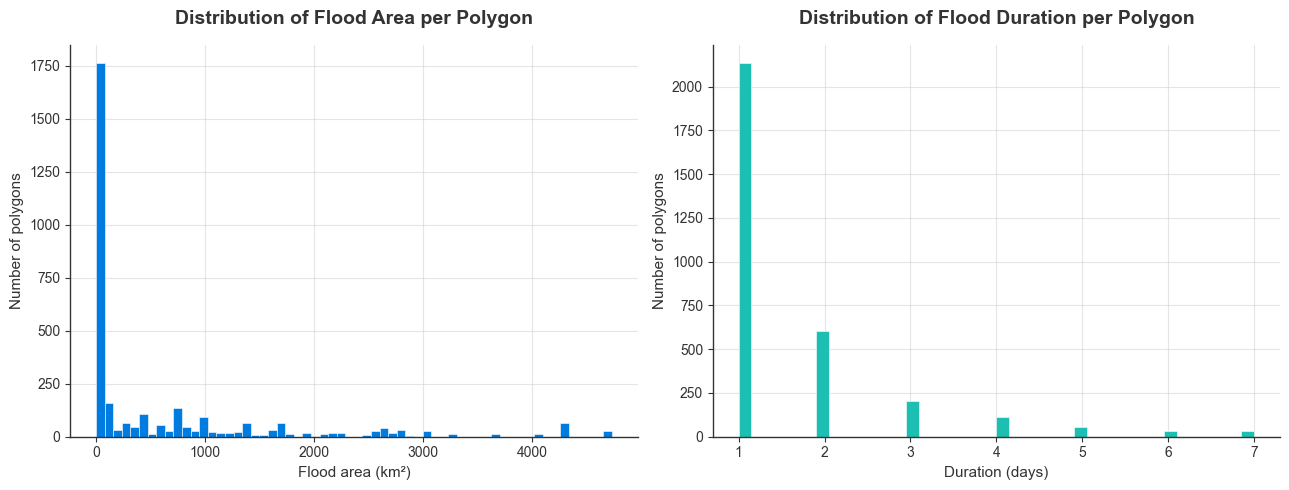

Area  — median: 38.7 km²,  mean: 609.5 km²,  max: 4727.3 km²
Duration — median: 1 days,  mean: 1.6 days,  max: 7 days


In [9]:
gdf_flood_sel["duration_days"] = (gdf_flood_sel["end_date"] - gdf_flood_sel["start_date"]).dt.days + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Flood area distribution
axes[0].hist(
    gdf_flood_sel["area_km2"],
    bins=60,
    color=OCHA_COLORS["ocha_blue"],
    edgecolor="white",
    linewidth=0.4,
)
axes[0].set_xlabel("Flood area (km²)")
axes[0].set_ylabel("Number of polygons")
axes[0].set_title("Distribution of Flood Area per Polygon", fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)

# Flood duration distribution
axes[1].hist(
    gdf_flood_sel["duration_days"],
    bins=40,
    color=OCHA_COLORS["teal"],
    edgecolor="white",
    linewidth=0.4,
)
axes[1].set_xlabel("Duration (days)")
axes[1].set_ylabel("Number of polygons")
axes[1].set_title("Distribution of Flood Duration per Polygon", fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/groundsource_area_duration_distributions.png", dpi=300)
plt.show()

print(f"Area  — median: {gdf_flood_sel['area_km2'].median():.1f} km²,  mean: {gdf_flood_sel['area_km2'].mean():.1f} km²,  max: {gdf_flood_sel['area_km2'].max():.1f} km²")
print(f"Duration — median: {gdf_flood_sel['duration_days'].median():.0f} days,  mean: {gdf_flood_sel['duration_days'].mean():.1f} days,  max: {gdf_flood_sel['duration_days'].max():.0f} days")

## Daily flood fraction per LGA

For each LGA and each day, compute the fraction of the LGA's area covered by flood extents.

In [10]:
CRS_METRIC = "EPSG:32633"  # UTM Zone 33N (Nigeria)

# --- 1. LGA areas in metric CRS ---
gdf_lga_m = gdf_lga_sel[["ADM2_PCODE", "ADM2_EN", "geometry"]].to_crs(CRS_METRIC).copy()
gdf_lga_m["lga_area_km2"] = gdf_lga_m.geometry.area / 1e6

# --- 2. Unique flood polygons that intersect any selected LGA ---
gdf_floods_m = (
    gdf_flood_sel[["uuid", "start_date", "end_date", "geometry"]]
    .drop_duplicates("uuid")
    .to_crs(CRS_METRIC)
)

# --- 3. Actual intersection area: loop over LGAs for progress tracking ---
overlap_parts = []
for _, lga_row in tqdm(gdf_lga_m.iterrows(), total=len(gdf_lga_m), desc="Intersecting floods with LGAs"):
    lga_geom = lga_row.geometry
    candidates = gdf_floods_m[gdf_floods_m.intersects(lga_geom)].copy()
    if candidates.empty:
        continue
    lga_gdf = gpd.GeoDataFrame([lga_row], crs=gdf_lga_m.crs)
    intersected = gpd.overlay(candidates, lga_gdf, how="intersection", keep_geom_type=False)
    intersected["overlap_km2"] = intersected.geometry.area / 1e6
    overlap_parts.append(intersected)

gdf_overlap = pd.concat(overlap_parts, ignore_index=True)
print(f"Flood–LGA intersection pairs: {len(gdf_overlap):,}")

Intersecting floods with LGAs:   0%|          | 0/97 [00:00<?, ?it/s]

Flood–LGA intersection pairs: 7,589


In [11]:
# --- 4. Expand each flood event to daily rows (keep geometry to union later) ---
df_pairs = gdf_overlap[["ADM2_PCODE", "ADM2_EN", "lga_area_km2", "start_date", "end_date", "geometry"]].copy()
df_pairs["start_date"] = pd.to_datetime(df_pairs["start_date"])
df_pairs["end_date"] = pd.to_datetime(df_pairs["end_date"])
df_pairs["n_days"] = (df_pairs["end_date"] - df_pairs["start_date"]).dt.days + 1

df_daily_raw = df_pairs.loc[df_pairs.index.repeat(df_pairs["n_days"])].copy()
df_daily_raw["day_offset"] = df_daily_raw.groupby(level=0).cumcount()
df_daily_raw["date"] = df_daily_raw["start_date"] + pd.to_timedelta(df_daily_raw["day_offset"], unit="D")

# --- 5. Union overlapping flood geometries per LGA per day, then compute area ---
# Summing pre-computed areas would double-count where source polygons overlap;
# unary_union dissolves those overlaps before measuring.
gdf_daily_raw = gpd.GeoDataFrame(df_daily_raw, geometry="geometry", crs=CRS_METRIC)

df_flooded = (
    gdf_daily_raw.groupby(["date", "ADM2_PCODE", "ADM2_EN", "lga_area_km2"])["geometry"]
    .agg(lambda geoms: unary_union(geoms).area / 1e6)
    .reset_index()
    .rename(columns={"geometry": "overlap_km2"})
)
df_flooded["flood_fraction"] = (df_flooded["overlap_km2"] / df_flooded["lga_area_km2"]).clip(0, 1)

# --- 6. Fill in zeros for unflooded LGA-days ---
full_dates = pd.date_range(df_flooded["date"].min(), df_flooded["date"].max(), freq="D")
lga_info = gdf_lga_m[["ADM2_PCODE", "ADM2_EN", "lga_area_km2"]]

df_all = (
    pd.MultiIndex.from_product([full_dates, lga_info["ADM2_PCODE"]], names=["date", "ADM2_PCODE"])
    .to_frame(index=False)
    .merge(lga_info, on="ADM2_PCODE")
    .merge(df_flooded[["date", "ADM2_PCODE", "overlap_km2", "flood_fraction"]], on=["date", "ADM2_PCODE"], how="left")
)
df_all["overlap_km2"] = df_all["overlap_km2"].fillna(0)
df_all["flood_fraction"] = df_all["flood_fraction"].fillna(0)
df_all = df_all.sort_values(["ADM2_PCODE", "date"]).reset_index(drop=True)

print(f"Output shape: {df_all.shape}")
print(f"Date range: {df_all['date'].min().date()} – {df_all['date'].max().date()}")
print(f"LGAs: {df_all['ADM2_PCODE'].nunique()}")
df_all.head(10)

Output shape: (783372, 6)
Date range: 2003-11-15 – 2025-12-24
LGAs: 97


,date,ADM2_PCODE,ADM2_EN,lga_area_km2,overlap_km2,flood_fraction
0,2003-11-15,NG002001,Demsa,1570.841023,0.0,0.0
1,2003-11-16,NG002001,Demsa,1570.841023,0.0,0.0
2,2003-11-17,NG002001,Demsa,1570.841023,0.0,0.0
3,2003-11-18,NG002001,Demsa,1570.841023,0.0,0.0
4,2003-11-19,NG002001,Demsa,1570.841023,0.0,0.0
5,2003-11-20,NG002001,Demsa,1570.841023,0.0,0.0
6,2003-11-21,NG002001,Demsa,1570.841023,0.0,0.0
7,2003-11-22,NG002001,Demsa,1570.841023,0.0,0.0
8,2003-11-23,NG002001,Demsa,1570.841023,0.0,0.0
9,2003-11-24,NG002001,Demsa,1570.841023,0.0,0.0


In [13]:
# stratus.upload_csv_to_blob(df_all, "ds-aa-nga-flooding/processed/groundsource_lga_daily_flood_fraction.csv")

## Return period heatmap by LGA and year

In [14]:
# Annual maximum flood fraction per LGA per year
df_all["year"] = df_all["date"].dt.year
df_annual_max = (
    df_all.groupby(["ADM2_PCODE", "ADM2_EN", "year"])["flood_fraction"]
    .max()
    .reset_index()
)

# Empirical return period per LGA (higher fraction = more severe)
df_rp = df_annual_max.copy()
df_rp["rank"] = (
    df_rp.groupby("ADM2_PCODE")["flood_fraction"]
    .rank(ascending=False, method="min")
    .astype(int)
)
df_rp["n_years"] = df_rp.groupby("ADM2_PCODE")["year"].transform("count")
df_rp["rp"] = (df_rp["n_years"] + 1) / df_rp["rank"]

# Merge HA assignment for grouping
df_rp = df_rp.merge(
    gdf_lga_sel[["ADM2_PCODE", "HA_assigned"]].drop_duplicates("ADM2_PCODE"),
    on="ADM2_PCODE",
    how="left",
)

print(f"LGAs: {df_rp['ADM2_PCODE'].nunique()}, Years: {sorted(df_rp['year'].unique())}")

LGAs: 97, Years: [np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


## Floodscan vs Groundsource comparison

Compare daily flood fraction from Google Groundsource (area-based) against Floodscan SFED (satellite signal) for each LGA.

In [16]:
gdf_nga = stratus.codab.load_codab_from_blob("NGA", 0)

In [17]:
# Select a small subset to start
dates = pd.date_range('2010-01-01', '2025-12-31').strftime('%Y-%m-%d').tolist()
ds_fs = stratus.stack_cogs("floodscan", dates, "prod", gdf_nga)

100%|██████████| 5844/5844 [42:42<00:00,  2.28it/s]  


In [ ]:
ds_fs.to_netcdf("floodscan_nga_1998_2025.nc")

In [18]:
container_client = stratus.get_container_client("web", stage="dev", write=True)

for date_val in tqdm(ds_fs.date.values, desc="Uploading COGs"):
    # Normalise date string to YYYY-MM-DD (stack_cogs can produce un-padded dates)
    date_str = datetime.strptime(str(date_val).strip()[:10], "%Y-%m-%d").strftime("%Y-%m-%d")

    da_date = ds_fs.sel(date=date_val).rio.write_crs("EPSG:4326")

    with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
        tmp_path = tmp.name

    da_date.rio.to_raster(tmp_path, driver="COG")

    blob_name = f"floodscan/daily/nga_clipped/{date_str}.tif"
    with open(tmp_path, "rb") as f:
        container_client.get_blob_client(blob_name).upload_blob(f, overwrite=True)
    os.unlink(tmp_path)

print("Done")

Uploading COGs:   0%|          | 0/5844 [00:00<?, ?it/s]

Done


In [21]:
ds_fs = ds_fs.sel(band=1)

In [22]:
# Clip the global Floodscan raster to only the pixels that overlap our selected LGAs.
# Pixels outside the LGA boundaries are set to NaN by rio.clip.
ds_lga = (
    ds_fs
    .rio.write_crs("EPSG:4326")
    .rio.clip(gdf_lga_sel.geometry, all_touched=True)
)

# Pull out the spatial metadata we need to rasterize flood polygons onto the same grid.
dates_arr = pd.to_datetime(ds_lga.date.values)
transform = ds_lga.rio.transform()   # affine transform: maps pixel indices → coordinates
shape = (ds_lga.sizes["y"], ds_lga.sizes["x"])  # raster grid dimensions

# Filter Groundsource flood polygons to the date range covered by ds_lga (2025),
# and clip their start/end dates to that range so date comparisons stay in bounds.
ds_start, ds_end = dates_arr.min(), dates_arr.max()
gdf_flood_period = gdf_flood_sel.drop_duplicates("uuid")[["start_date", "end_date", "geometry"]].copy()
gdf_flood_period["start_date"] = pd.to_datetime(gdf_flood_period["start_date"]).clip(lower=ds_start)
gdf_flood_period["end_date"] = pd.to_datetime(gdf_flood_period["end_date"]).clip(upper=ds_end)
gdf_flood_period = gdf_flood_period[gdf_flood_period["end_date"] >= ds_start]

# For each date, burn the flood polygons that were active on that date into a boolean
# raster mask. rasterize() sets pixels overlapping a polygon to 1, all others to 0.
flooded_masks = []
for date in dates_arr:
    active_geoms = gdf_flood_period.loc[
        (gdf_flood_period["start_date"] <= date) & (gdf_flood_period["end_date"] >= date),
        "geometry"
    ]
    if active_geoms.empty:
        flooded_masks.append(np.zeros(shape, dtype=bool))
    else:
        flooded_masks.append(
            rasterize(active_geoms, out_shape=shape, transform=transform,
                      fill=0, default_value=1, dtype="uint8").astype(bool)
        )

# Stack the per-date masks into a single DataArray with the same coordinates as ds_lga,
# so we can merge it with the SFED values on (date, y, x).
da_flooded = xr.DataArray(
    np.stack(flooded_masks),
    coords={"date": ds_lga.date, "y": ds_lga.y, "x": ds_lga.x},
    dims=["date", "y", "x"],
)

# Flatten ds_lga to a long DataFrame of (date, y, x, sfed), dropping NaN pixels
# (those outside the LGA boundaries that were masked by rio.clip).
df_sfed = (
    ds_lga.to_dataframe(name="sfed")
    .reset_index()[["date", "y", "x", "sfed"]]
    .dropna(subset=["sfed"])
    .assign(date=lambda d: pd.to_datetime(d["date"]))
)

# Flatten the flooded mask to the same long format, then join onto df_sfed.
# Every pixel-date row now has a boolean flooded flag from Groundsource.
df_flooded_flag = (
    da_flooded.to_dataframe(name="flooded")
    .reset_index()[["date", "y", "x", "flooded"]]
    .assign(date=lambda d: pd.to_datetime(d["date"]))
)

df_sfed = df_sfed.merge(df_flooded_flag, on=["date", "y", "x"], how="left")
df_sfed["flooded"] = df_sfed["flooded"].astype(bool)
print(f"Total pixel-date obs: {len(df_sfed):,}  |  flooded: {df_sfed['flooded'].sum():,}  |  not flooded: {(~df_sfed['flooded']).sum():,}")

Total pixel-date obs: 16,474,236  |  flooded: 29,524  |  not flooded: 16,444,712


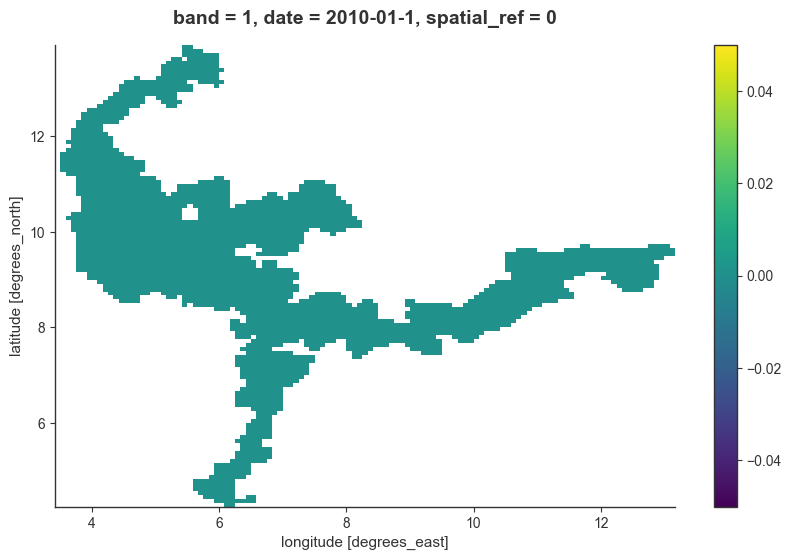

In [23]:
ds_lga.isel(date=0).plot()

/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/ipykernel_59124/2371020917.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


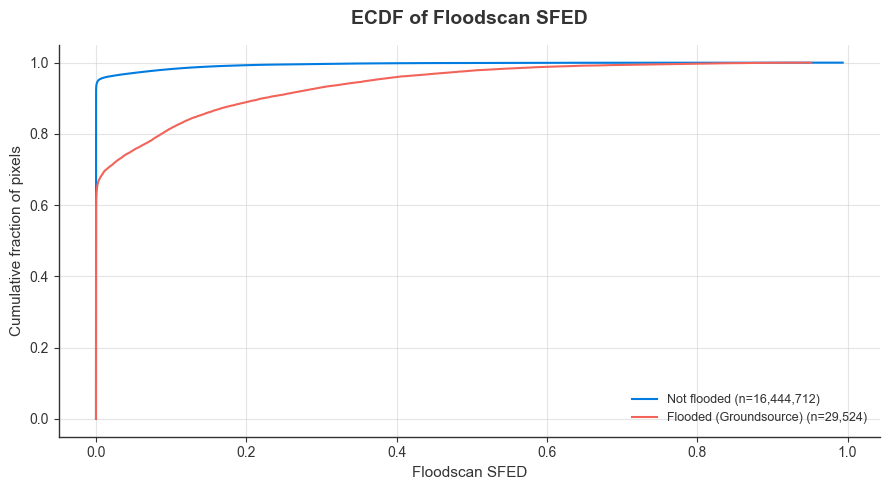

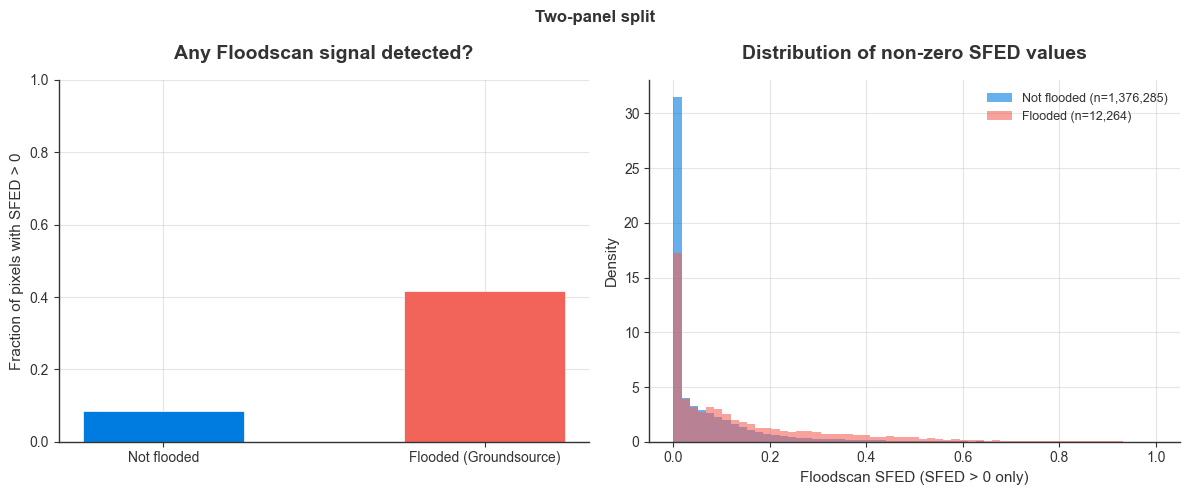

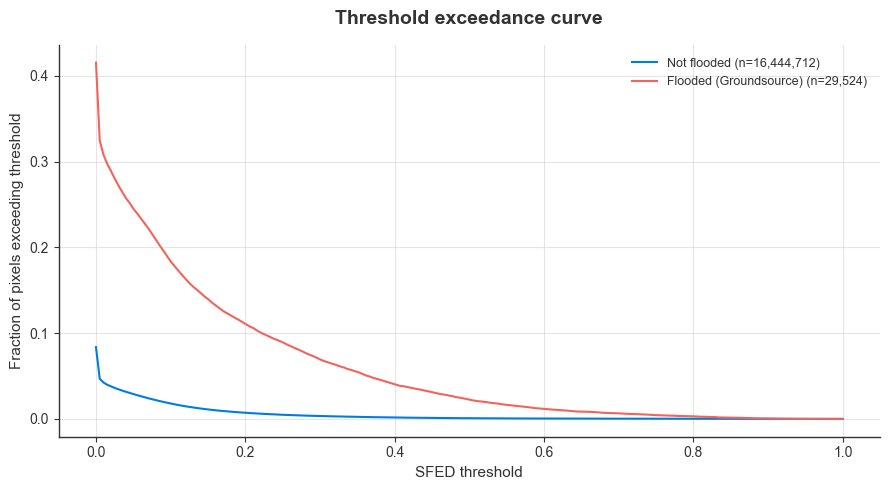

In [28]:
sfed_flooded = df_sfed[df_sfed["flooded"]]["sfed"].values
sfed_not_flooded = df_sfed[~df_sfed["flooded"]]["sfed"].values
colors = [OCHA_COLORS["ocha_blue"], OCHA_COLORS["coral"]]
labels = ["Not flooded", "Flooded (Groundsource)"]

# ── 1. ECDF ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for vals, color, label in zip([sfed_not_flooded, sfed_flooded], colors, labels):
    sorted_vals = np.sort(vals)
    ecdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    ax.plot(sorted_vals, ecdf, color=color, linewidth=1.5, label=f"{label} (n={len(vals):,})")
ax.set_xlabel("Floodscan SFED")
ax.set_ylabel("Cumulative fraction of pixels")
ax.set_title("ECDF of Floodscan SFED", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── 2. Two-panel split ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: fraction of pixels with any Floodscan signal (sfed > 0)
frac_nonzero = {
    label: (vals > 0).mean()
    for vals, label in zip([sfed_not_flooded, sfed_flooded], labels)
}
axes[0].bar(frac_nonzero.keys(), frac_nonzero.values(),
            color=colors, edgecolor="white", width=0.5)
axes[0].set_ylabel("Fraction of pixels with SFED > 0")
axes[0].set_title("Any Floodscan signal detected?", fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].spines[["top", "right"]].set_visible(False)

# Panel 2: distribution of non-zero SFED values only
sfed_flooded_pos = sfed_flooded[sfed_flooded > 0]
sfed_not_flooded_pos = sfed_not_flooded[sfed_not_flooded > 0]
bins = np.linspace(0, 1, 60)
axes[1].hist(sfed_not_flooded_pos, bins=bins, density=True, alpha=0.6,
             color=colors[0], label=f"Not flooded (n={len(sfed_not_flooded_pos):,})")
axes[1].hist(sfed_flooded_pos, bins=bins, density=True, alpha=0.6,
             color=colors[1], label=f"Flooded (n={len(sfed_flooded_pos):,})")
axes[1].set_xlabel("Floodscan SFED (SFED > 0 only)")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of non-zero SFED values", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Two-panel split", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

# ── 3. Threshold exceedance curve ────────────────────────────────────────────
thresholds = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(9, 5))
for vals, color, label in zip([sfed_not_flooded, sfed_flooded], colors, labels):
    exceedance = [(vals > t).mean() for t in thresholds]
    ax.plot(thresholds, exceedance, color=color, linewidth=1.5,
            label=f"{label} (n={len(vals):,})")
ax.set_xlabel("SFED threshold")
ax.set_ylabel("Fraction of pixels exceeding threshold")
ax.set_title("Threshold exceedance curve", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures/groundsource_floodscan_exceedance_curve.png", dpi=300)